In [6]:
import requests
import io
import pandas as pd


def load_smet(url, tz="Europe/Vienna"):
    r = requests.get(url, timeout=60, headers={"User-Agent": "python"})
    r.raise_for_status()

    # 👉 KEIN gzip!
    text = r.text

    lines = text.splitlines()

    header = {}
    data_start = None

    for i, line in enumerate(lines):
        s = line.strip()

        if s.upper() == "[DATA]":
            data_start = i + 1
            break

        if "=" in s and not s.startswith("#"):
            k, v = s.split("=", 1)
            header[k.strip().lower()] = v.strip()

    if data_start is None:
        raise ValueError("SMET [DATA] section not found")

    fields = header["fields"].split()

    df = pd.read_csv(
        io.StringIO("\n".join(lines[data_start:])),
        sep=r"\s+",
        names=fields,
        engine="python",
    )

    # Zeitindex
    if "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"])
        df = df.drop(columns=["timestamp"])
        df.index = idx.tz_localize("UTC").tz_convert(tz)

    # nodata ersetzen
    if "nodata" in header:
        df = df.replace(float(header["nodata"]), pd.NA)

    return df, header

In [7]:
url = "https://api.avalanche.report/lawine/grafiken/smet/woche/ACOM1.smet.gz"

df, hdr = load_smet(url)

df.head()

TypeError: index is not a valid DatetimeIndex or PeriodIndex

In [8]:
import requests

url = "https://api.avalanche.report/lawine/grafiken/smet/woche/ACOM1.smet.gz"
r = requests.get(url, timeout=60, headers={"User-Agent": "python"})
print("status:", r.status_code)
print("content-type:", r.headers.get("content-type"))
print("first 200 chars:\n", r.text[:200])

status: 200
content-type: plain/text
first 200 chars:
 SMET 1.1 ASCII
[HEADER]
station_id = ACOM1
station_name = Assling Compedal Windstation
latitude = 46.8047
longitude = 12.6097
altitude = 2180.0
source = LWD Tirol
nodata = -777
creation = 202


In [9]:
text = r.text
lines = text.splitlines()

for i, line in enumerate(lines[:60]):
    print(f"{i:02d} {line}")

00 SMET 1.1 ASCII
01 [HEADER]
02 station_id = ACOM1
03 station_name = Assling Compedal Windstation
04 latitude = 46.8047
05 longitude = 12.6097
06 altitude = 2180.0
07 source = LWD Tirol
08 nodata = -777
09 creation = 2026-03-01T19:08:15.724250400Z
10 fields = timestamp DW VW VW_MAX RH TA TD
11 #parameters = timestamp WR WG WG.Boe LF LT TP
12 #units = ISO8601 Â° m/s m/s 1 K K
13 [DATA]
14 2026-02-22T19:10:00Z 265 2.82 3.59 0.602 274.55 267.696499258
15 2026-02-22T19:20:00Z 247 3.21 4.23 0.607 274.45 267.710613709
16 2026-02-22T19:30:00Z 264 3.15 4.62 0.609 274.45 267.753774254
17 2026-02-22T19:40:00Z 259 2.14 2.93 0.59 274.45 267.338568421
18 2026-02-22T19:50:00Z 268 2.02 3.57 0.564 274.55 266.844388299
19 2026-02-22T20:00:00Z 264 2.6 3.64 0.601 274.35 267.486045335
20 2026-02-22T20:10:00Z 271 2.99 4.24 0.624 274.05 267.694607396
21 2026-02-22T20:20:00Z 256 3.31 4.35 0.59 274.25 267.150307983
22 2026-02-22T20:30:00Z 257 2.68 3.57 0.53 274.75 266.223620259
23 2026-02-22T20:40:00Z 261 2.

In [14]:
import requests, io
import pandas as pd

def load_lwd_smet(url: str, tz="Europe/Vienna"):
    r = requests.get(url, timeout=60, headers={"User-Agent": "python"})
    r.raise_for_status()
    lines = r.text.splitlines()

    header = {}
    data_start = None
    for i, line in enumerate(lines):
        s = line.strip()
        if s.upper() == "[DATA]":
            data_start = i + 1
            break
        if "=" in s and not s.startswith("#"):
            k, v = s.split("=", 1)
            header[k.strip().lower()] = v.strip()

    if data_start is None:
        raise ValueError("SMET: [DATA] section not found")

    fields = header["fields"].split()

    df = pd.read_csv(
        io.StringIO("\n".join(lines[data_start:])),
        sep=r"\s+",
        names=fields,
        engine="python",
    )

    # Zeitindex: UTC -> Europe/Vienna
    t = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.drop(columns=["timestamp"])
    df.index = t.dt.tz_convert(tz)
    df = df.sort_index()

    # nodata ersetzen
    nodata = header.get("nodata")
    if nodata is not None:
        try:
            df = df.replace(float(nodata), pd.NA)
        except Exception:
            pass

    return df, header

In [15]:
def prepare_lwd_weather(df):
    out = df.copy()

    # Kelvin -> °C
    if "TA" in out.columns:
        out["TA_C"] = out["TA"] - 273.15
    if "TD" in out.columns:
        out["TD_C"] = out["TD"] - 273.15

    # RH 0..1 -> %
    if "RH" in out.columns:
        out["RH_pct"] = out["RH"] * 100.0

    # Wind m/s -> km/h (optional, ich find km/h für Gefühl oft besser)
    if "VW" in out.columns:
        out["VW_kmh"] = out["VW"] * 3.6
    if "VW_MAX" in out.columns:
        out["VW_MAX_kmh"] = out["VW_MAX"] * 3.6

    return out

In [16]:
import matplotlib.pyplot as plt

def plot_dual_subplots(df, pairs, figsize=(14, 7), sharex=True):
    n = len(pairs)
    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=sharex, constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (left_col, right_col) in zip(axes, pairs):
        left_color = "tab:blue"
        right_color = "tab:orange"

        ax.plot(df.index, df[left_col], color=left_color, linewidth=1.8, label=left_col)
        ax.set_ylabel(left_col, color=left_color)
        ax.tick_params(axis="y", colors=left_color)
        ax.spines["left"].set_color(left_color)
        ax.grid(True, alpha=0.3)

        ax_r = ax.twinx()
        ax_r.plot(df.index, df[right_col], color=right_color, linestyle="--", linewidth=1.6, label=right_col)
        ax_r.set_ylabel(right_col, color=right_color)
        ax_r.tick_params(axis="y", colors=right_color)
        ax_r.spines["right"].set_color(right_color)

        lines = ax.get_lines() + ax_r.get_lines()
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="upper left")

    return fig, axes

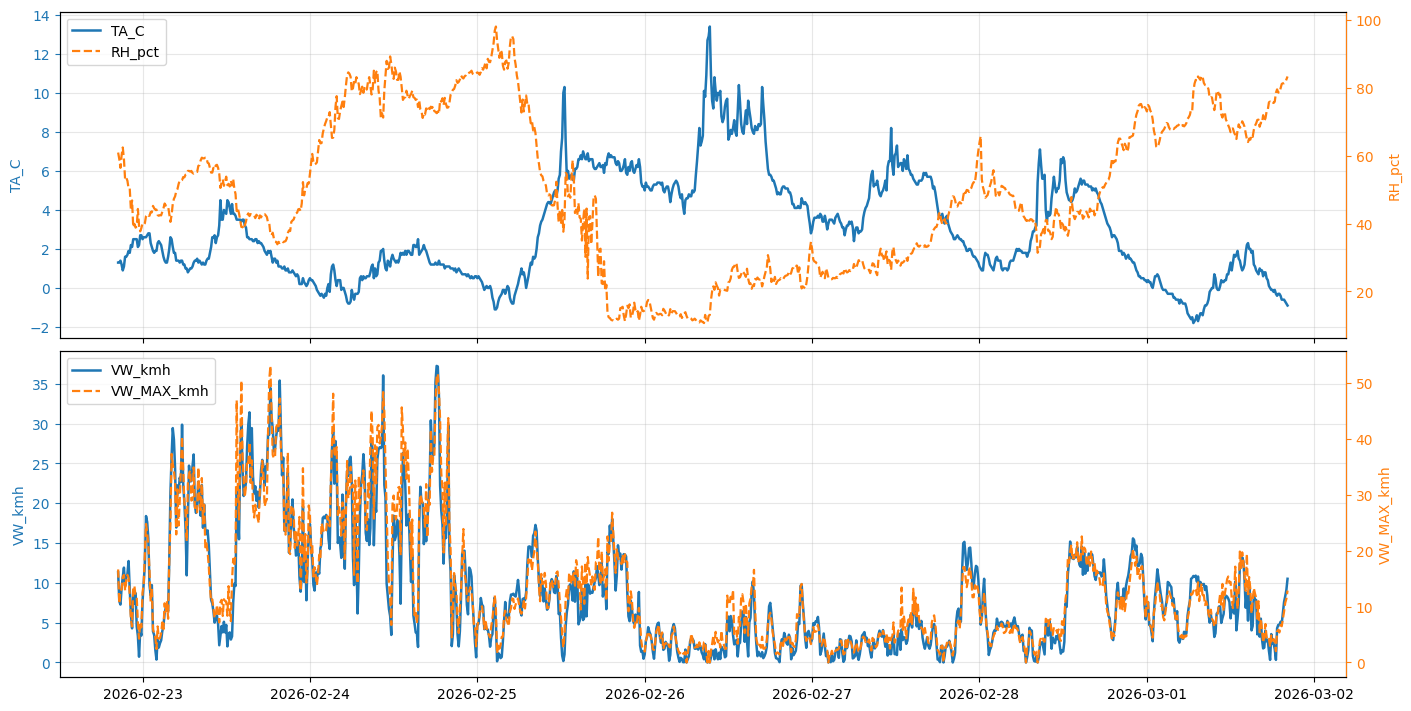

Assling Compedal Windstation 2180.0 LWD Tirol


In [19]:
url = "https://api.avalanche.report/lawine/grafiken/smet/woche/ACOM1.smet.gz"

df_raw, hdr = load_lwd_smet(url)
df = prepare_lwd_weather(df_raw)

fig, axes = plot_dual_subplots(
    df,
    pairs=[
        ("TA_C", "RH_pct"),         # oben
        ("VW_kmh", "VW_MAX_kmh"),   # unten
    ],
    figsize=(14, 7),
)
plt.show()

print(hdr["station_name"], hdr["altitude"], hdr["source"])

In [20]:
import requests

test = "https://api.avalanche.report/lawine/grafiken/smet/woche/2026-02-15/ACOM1.smet.gz"
print(requests.head(test).status_code)

404


In [27]:
import ssl
import certifi

ssl._create_default_https_context = ssl.create_default_context(
    cafile=certifi.where()
)

In [ ]:
import requests
import pandas as pd
import io

url = "https://wiski.tirol.gv.at/lawine/produkte/ogd/ACOM1/ACOM1_LT_latest.csv"

r = requests.get(url, timeout=60)
r.raise_for_status()

#df = pd.read_csv(cringIO(r.text))

#df.head()

In [32]:
r

<Response [200]>

In [33]:
r.text

'Stationsmessort;Assling\r\nStationsname;Assling Compedal Windstation\r\nStationsnummer;1197082\r\nStationshöhe;2180\r\nPegelnullpunkt [];\r\nMesspunkthöhe [];\r\nGeländeoberkante [];\r\nParametername;LT\r\nZeitreihenname;Basisganglinie\r\nPfad der Zeitreihe;20102/1197082/LT/Cmd\r\nEinheit der Zeitreihe;°C\r\nZeitzone;+01:00\r\nGeografische Länge;46,8047\r\nGeografische Breite;12,6097\r\nFehlwertkennzeichner;---\r\nDatum/Uhrzeit;Wert [°C]\r\n22.02.2026 21:00:00;1,2\r\n22.02.2026 21:10:00;0,9\r\n22.02.2026 21:20:00;1,1\r\n22.02.2026 21:30:00;1,6\r\n22.02.2026 21:40:00;1,6\r\n22.02.2026 21:50:00;1,7\r\n22.02.2026 22:00:00;1,9\r\n22.02.2026 22:10:00;1,8\r\n22.02.2026 22:20:00;2,2\r\n22.02.2026 22:30:00;2,1\r\n22.02.2026 22:40:00;2,5\r\n22.02.2026 22:50:00;2,5\r\n22.02.2026 23:00:00;2,5\r\n22.02.2026 23:10:00;2,5\r\n22.02.2026 23:20:00;2,1\r\n22.02.2026 23:30:00;2,2\r\n22.02.2026 23:40:00;2,7\r\n22.02.2026 23:50:00;2,7\r\n23.02.2026 00:00:00;2,5\r\n23.02.2026 00:10:00;2,6\r\n23.02.2026 00:

In [34]:
import requests
import pandas as pd
import io

url = "https://wiski.tirol.gv.at/lawine/produkte/ogd/ACOM1/ACOM1_LT_latest.csv"

r = requests.get(url, timeout=60)
r.raise_for_status()

raw = r.content  # bytes!
print(len(raw), raw[:20])

25527 b'Stationsmessort;Assl'


In [35]:
def decode_bytes(raw: bytes) -> str:
    for enc in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            pass
    # letzter fallback: ersetzen statt crashen
    return raw.decode("utf-8", errors="replace")

text = decode_bytes(raw)
print(text.splitlines()[0:5])

['Stationsmessort;Assling', 'Stationsname;Assling Compedal Windstation', 'Stationsnummer;1197082', 'Stationshöhe;2180', 'Pegelnullpunkt [];']


In [36]:
def parse_wiski_ogd_csv(text: str, tz="Europe/Vienna"):
    lines = text.splitlines()

    # Metadaten key;value einsammeln bis Datenheader
    meta = {}
    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith("Datum/Uhrzeit;"):
            start = i
            break
        if ";" in line:
            k, v = line.split(";", 1)
            meta[k.strip()] = v.strip()

    if start is None:
        raise ValueError("Datenheader 'Datum/Uhrzeit;...' nicht gefunden.")

    data_text = "\n".join(lines[start:])

    df = pd.read_csv(
        io.StringIO(data_text),
        sep=";",
        decimal=",",          # deutsches Komma
        na_values=["---"],    # Fehlwertkennzeichner :contentReference[oaicite:2]{index=2}
    )

    # Spaltennamen aus deinem Format: "Datum/Uhrzeit", "Wert [°C]" :contentReference[oaicite:3]{index=3}
    time_col = df.columns[0]
    val_col = df.columns[1]

    df[time_col] = pd.to_datetime(df[time_col], dayfirst=True, errors="coerce")
    df = df.set_index(time_col).sort_index()

    # Zeitzone aus Metainfo (+01:00) steht drin :contentReference[oaicite:4]{index=4}
    # Das sind lokale Zeitstempel (ohne DST-Info). Wir lokalisieren nach Europe/Vienna.
    df.index = df.index.tz_localize("Europe/Vienna", ambiguous="infer", nonexistent="shift_forward")

    df = df.rename(columns={val_col: meta.get("Parametername", "value")})
    return df, meta

df, meta = parse_wiski_ogd_csv(text)
df.head(), meta.get("Stationsname"), meta.get("Parametername")

(                            LT
 Datum/Uhrzeit                 
 2026-02-22 21:00:00+01:00  1.2
 2026-02-22 21:10:00+01:00  0.9
 2026-02-22 21:20:00+01:00  1.1
 2026-02-22 21:30:00+01:00  1.6
 2026-02-22 21:40:00+01:00  1.6,
 'Assling Compedal Windstation',
 'LT')

<Axes: xlabel='Datum/Uhrzeit'>

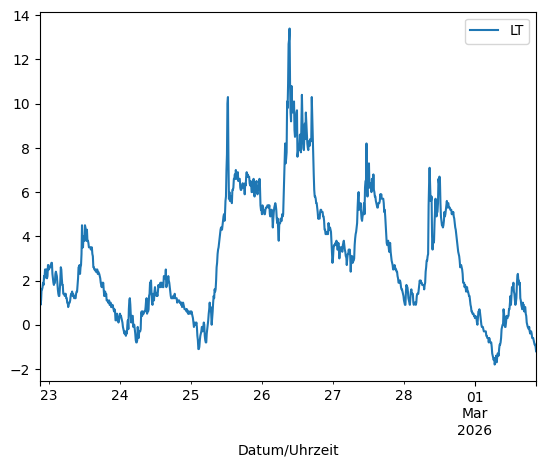

In [37]:
df.plot()

In [38]:
def load_station_params(station="ACOM1", params=("LT","LF","WG","WG.Boe"), tz="Europe/Vienna"):
    dfs = []
    metas = {}
    for p in params:
        url = f"https://wiski.tirol.gv.at/lawine/produkte/ogd/{station}/{station}_{p}_latest.csv"
        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            continue
        text = decode_bytes(r.content)
        df_p, meta = parse_wiski_ogd_csv(text, tz=tz)
        dfs.append(df_p.rename(columns={meta.get("Parametername","value"): p}))
        metas[p] = meta
    if not dfs:
        raise ValueError("Keine Parameter geladen (URLs prüfen).")
    df = pd.concat(dfs, axis=1).sort_index()
    return df, metas

df, metas = load_station_params("ACOM1", params=("LT","LF","WG","WG.Boe"))
df.head()

,LT,LF,WG,WG.Boe
Datum/Uhrzeit,,,,
2026-02-22 21:10:00+01:00,0.9,62.4,2.99,4.24
2026-02-22 21:20:00+01:00,1.1,59.0,3.31,4.35
2026-02-22 21:30:00+01:00,1.6,53.0,2.68,3.57
2026-02-22 21:40:00+01:00,1.6,53.5,2.98,4.09
2026-02-22 21:50:00+01:00,1.7,52.6,3.09,4.35


(<Figure size 1400x700 with 4 Axes>,
 array([<Axes: ylabel='LT'>, <Axes: ylabel='WG_kmh'>], dtype=object))

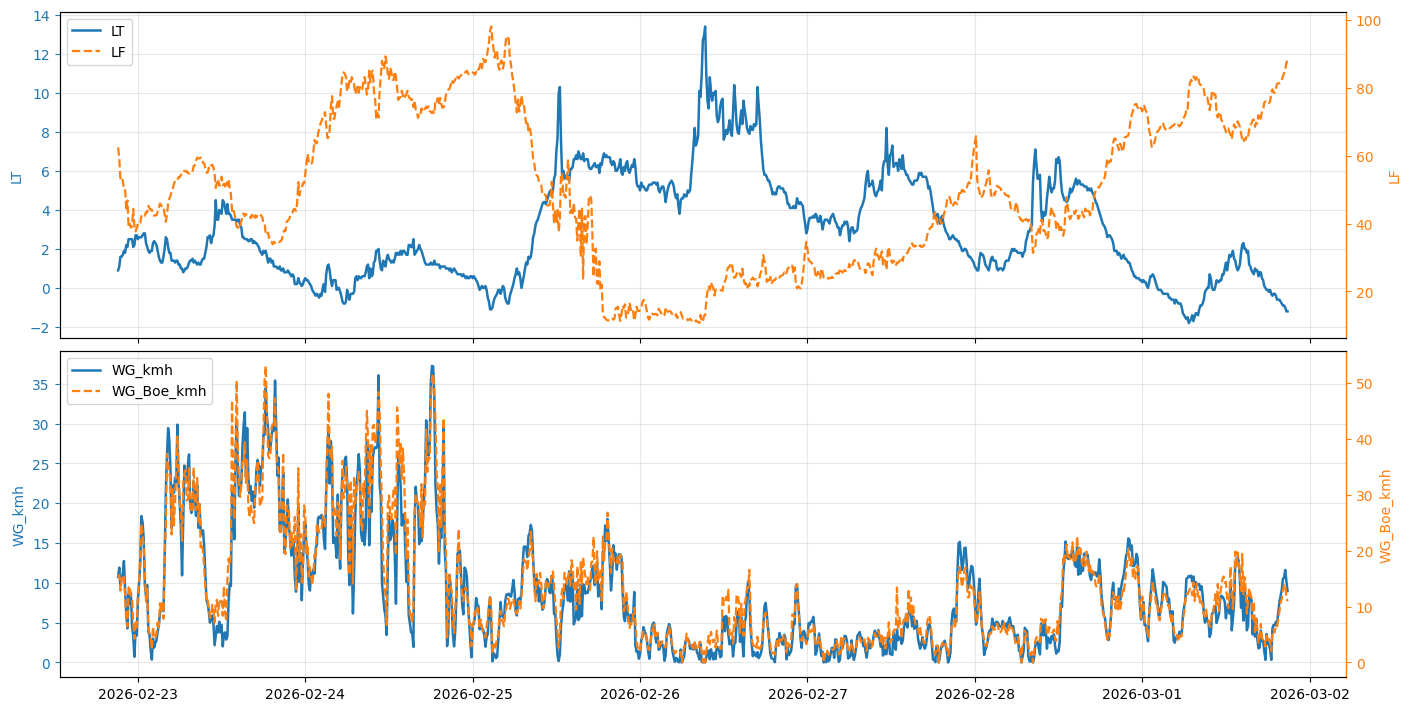

In [39]:
df_plot = df.copy()
df_plot["WG_kmh"] = df_plot["WG"] * 3.6
df_plot["WG_Boe_kmh"] = df_plot["WG.Boe"] * 3.6

plot_dual_subplots(
    df_plot,
    pairs=[
        ("LT", "LF"),              # °C und % (LF ist meistens schon %)
        ("WG_kmh", "WG_Boe_kmh"),
    ],
    figsize=(14, 7),
)

In [ ]:
v